# Effective Mass Notebook

Run the cells from top to bottom. For most runs, edit only the **Settings** cell below. The numerical work is imported from `effective_mass.py`, so this notebook stays in sync with the script.

In [1]:
from pathlib import Path
import os

import numpy as np
from IPython.display import Markdown, display

# Keep matplotlib's cache in a writable location when running from managed environments.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-effective-mass")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

from effective_mass import (
    parse_band_dat,
    convert_k_to_inv_angstrom,
    locate_band_edges,
    fit_effective_mass,
    _plot,
)

print("Ready. Imported calculation helpers from effective_mass.py")

Ready. Imported calculation helpers from effective_mass.py


## Settings

Change these values, then run the remaining cells.

In [2]:
# Input file
band_file = Path("BAND.dat")

# Band-edge detection. Leave as None to auto-detect with EF = 0.
efermi = None
vbm_band = None  # 0-based index, for example: 111
cbm_band = None  # 0-based index, for example: 112

# Fit controls
npoints = 7
order = 2

# k-axis units in the BAND.dat file: "1/A", "1/nm", "2pi/a", or "frac"
kunit = "1/A"
alat = None  # lattice parameter in Angstrom, needed only for "2pi/a" or "frac"

# Plot controls
make_plot = True
save_plot = None  # for example: Path("effective_mass_fit.png")

## Load Data

In [3]:
if not band_file.is_file():
    raise FileNotFoundError(f"Could not find {band_file.resolve()}")

bd = parse_band_dat(band_file)
k_invA = convert_k_to_inv_angstrom(bd.k, kunit, alat)

print(f"Parsed {band_file}: {bd.nkpts} k-points, {bd.nbands} bands")
print(f"k range: {k_invA.min():+.5f} to {k_invA.max():+.5f} 1/Angstrom")

Parsed BAND.dat: 140 k-points, 192 bands
k range: +0.00000 to +3.46184 1/Angstrom


## Choose Band Edges

In [4]:
if (vbm_band is None) != (cbm_band is None):
    raise ValueError("Set both vbm_band and cbm_band, or leave both as None for auto-detection.")

if vbm_band is not None and cbm_band is not None:
    vb_idx, cb_idx = int(vbm_band), int(cbm_band)
    print(f"Using user-specified bands: VBM=#{vb_idx}, CBM=#{cb_idx}")
else:
    vb_idx, cb_idx = locate_band_edges(bd, efermi=efermi)
    print(f"Auto-detected band edges: VBM=#{vb_idx}, CBM=#{cb_idx}")

Auto-detected band edges: VBM=#111, CBM=#112


## Fit Effective Masses

In [5]:
cb_fit = fit_effective_mass(
    k_invA,
    bd.energies[:, cb_idx],
    extremum="CBM",
    band_index=cb_idx,
    npoints=npoints,
    order=order,
)

vb_fit = fit_effective_mass(
    k_invA,
    bd.energies[:, vb_idx],
    extremum="VBM",
    band_index=vb_idx,
    npoints=npoints,
    order=order,
)

egap = cb_fit.E0 - vb_fit.E0
direct = abs(cb_fit.k0 - vb_fit.k0) < 1e-4

table = f"""
| Quantity | Electron (CBM) | Hole (VBM) |
|---|---:|---:|
| Band index | {cb_fit.band_index} | {vb_fit.band_index} |
| k0 (1/Angstrom) | {cb_fit.k0:+.5f} | {vb_fit.k0:+.5f} |
| E0 (eV) | {cb_fit.E0:+.5f} | {vb_fit.E0:+.5f} |
| Curvature c2 (eV Angstrom^2) | {cb_fit.a:+.5f} | {vb_fit.a:+.5f} |
| m*/m0 | {cb_fit.m_eff_over_m0:+.5f} | {abs(vb_fit.m_eff_over_m0):+.5f} |
| Fit RMS (meV) | {cb_fit.rms_eV * 1e3:.3f} | {vb_fit.rms_eV * 1e3:.3f} |
"""

display(Markdown(table))
print(f"Band gap E_g = {egap:.4f} eV ({'direct' if direct else 'indirect'})")
print(f"Fit window = {npoints} points, polynomial order = {order}")


| Quantity | Electron (CBM) | Hole (VBM) |
|---|---:|---:|
| Band index | 112 | 111 |
| k0 (1/Angstrom) | +0.00000 | +0.63063 |
| E0 (eV) | +4.83883 | -0.22108 |
| Curvature c2 (eV Angstrom^2) | +7.91932 | -1.34622 |
| m*/m0 | +0.48110 | +2.83014 |
| Fit RMS (meV) | 1.057 | 0.553 |


Band gap E_g = 5.0599 eV (indirect)
Fit window = 7 points, polynomial order = 2


## Plot

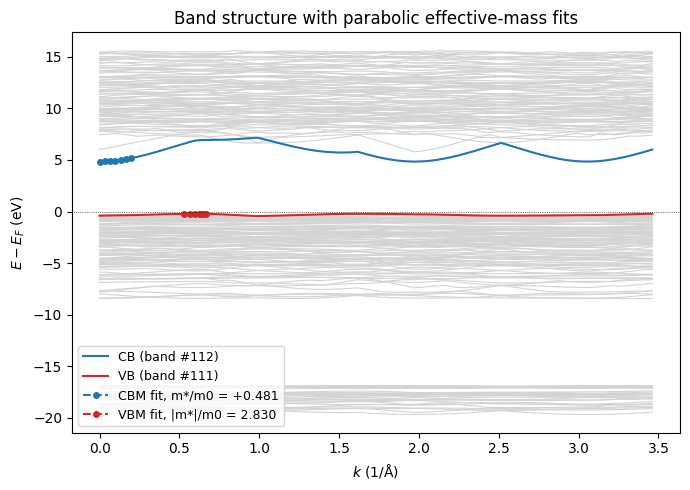

In [6]:
if make_plot:
    _plot(
        bd,
        k_invA,
        vb_idx,
        cb_idx,
        vb_fit,
        cb_fit,
        show=True,
        savepath=save_plot,
    )
else:
    print("Plot disabled. Set make_plot = True in the settings cell to show it.")

## Optional Command-Line Run

This mirrors the notebook settings using the script directly.

In [7]:
cmd = ["python3", "effective_mass.py", str(band_file), "--npoints", str(npoints), "--order", str(order), "--kunit", kunit]
if efermi is not None:
    cmd.extend(["--efermi", str(efermi)])
if vbm_band is not None and cbm_band is not None:
    cmd.extend(["--vbm-band", str(vbm_band), "--cbm-band", str(cbm_band)])
if alat is not None:
    cmd.extend(["--alat", str(alat)])
if make_plot:
    cmd.append("--plot")
if save_plot is not None:
    cmd.extend(["--save-plot", str(save_plot)])

print(" ".join(cmd))

python3 effective_mass.py BAND.dat --npoints 7 --order 2 --kunit 1/A --plot


## Optional: Band Gap Diagram

Run this after the effective-mass fit cells if you want a clearer band-gap figure. It highlights the VBM and CBM bands, marks the band-edge points, labels the band gap value, and adds high-symmetry k-point labels. Edit the labels in the next cell to match your actual KPOINTS path.

In [ ]:
# Optional band-gap diagram settings

def find_high_symmetry_points(k_values, atol=1e-8):
    points = [float(k_values[0])]
    for i in range(1, len(k_values)):
        if np.isclose(k_values[i], k_values[i - 1], atol=atol):
            points.append(float(k_values[i]))
    points.append(float(k_values[-1]))

    unique_points = []
    for point in points:
        if not unique_points or not np.isclose(point, unique_points[-1], atol=atol):
            unique_points.append(point)
    return unique_points


# Auto-detected k-path break points. Edit these manually if your file needs it.
high_symmetry_points = find_high_symmetry_points(k_invA)

# Edit these labels to match your band path, for example Gamma-Delta-X-M-Gamma-R-L-K.
label_pool = [r"$\Gamma$", r"$\Delta$", "X", "M", r"$\Gamma$", "R", "L", "K"]
high_symmetry_labels = [
    label_pool[i] if i < len(label_pool) else f"K{i}"
    for i in range(len(high_symmetry_points))
]

# Plot appearance
band_gap_y_padding = 1.0
save_band_gap_diagram = None  # Example: Path("band_gap_diagram.png")

print("High-symmetry points used for the diagram:")
for label, point in zip(high_symmetry_labels, high_symmetry_points):
    print(f"  {label:>10s}  k = {point:.5f} 1/Angstrom")

In [ ]:
import matplotlib.pyplot as plt


def nearest_k_label(k0, points, labels, atol=1e-3):
    points_array = np.array(points, dtype=float)
    nearest_index = int(np.argmin(np.abs(points_array - k0)))
    if abs(points_array[nearest_index] - k0) <= atol:
        return labels[nearest_index]
    return f"k={k0:.3f}"


def plot_band_gap_diagram(
    bd,
    k_invA,
    vb_idx,
    cb_idx,
    vb_fit,
    cb_fit,
    high_symmetry_points,
    high_symmetry_labels,
    y_padding=1.0,
    savepath=None,
):
    if len(high_symmetry_points) != len(high_symmetry_labels):
        raise ValueError("high_symmetry_points and high_symmetry_labels must have the same length.")

    egap = cb_fit.E0 - vb_fit.E0
    direct = abs(cb_fit.k0 - vb_fit.k0) < 1e-4
    gap_type = "direct" if direct else "indirect"
    vb_location = nearest_k_label(vb_fit.k0, high_symmetry_points, high_symmetry_labels)
    cb_location = nearest_k_label(cb_fit.k0, high_symmetry_points, high_symmetry_labels)

    x_min = float(np.min(k_invA))
    x_max = float(np.max(k_invA))
    x_span = x_max - x_min
    y_min = min(vb_fit.E0, cb_fit.E0) - y_padding
    y_max = max(vb_fit.E0, cb_fit.E0) + y_padding

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    ax.axhspan(vb_fit.E0, cb_fit.E0, color="#fde68a", alpha=0.35, label="Band gap")

    for band in range(bd.nbands):
        ax.plot(k_invA, bd.energies[:, band], color="0.82", lw=0.65, zorder=1)

    ax.plot(k_invA, bd.energies[:, vb_idx], color="#dc2626", lw=2.2, label=f"VBM band #{vb_idx}", zorder=3)
    ax.plot(k_invA, bd.energies[:, cb_idx], color="#2563eb", lw=2.2, label=f"CBM band #{cb_idx}", zorder=3)

    ax.scatter([vb_fit.k0], [vb_fit.E0], s=80, color="#dc2626", edgecolor="white", linewidth=0.9, zorder=4)
    ax.scatter([cb_fit.k0], [cb_fit.E0], s=80, color="#2563eb", edgecolor="white", linewidth=0.9, zorder=4)

    for point in high_symmetry_points:
        ax.axvline(point, color="0.35", lw=0.8, alpha=0.55, zorder=0)

    ax.axhline(vb_fit.E0, color="#dc2626", lw=1.0, ls="--", alpha=0.75)
    ax.axhline(cb_fit.E0, color="#2563eb", lw=1.0, ls="--", alpha=0.75)

    arrow_x = 0.5 * (vb_fit.k0 + cb_fit.k0)
    if direct:
        arrow_x = cb_fit.k0 + 0.05 * x_span
    arrow_x = min(max(arrow_x, x_min + 0.08 * x_span), x_max - 0.08 * x_span)
    text_x = min(arrow_x + 0.03 * x_span, x_max - 0.02 * x_span)

    ax.plot([vb_fit.k0, arrow_x], [vb_fit.E0, vb_fit.E0], color="#dc2626", lw=1.0, ls=":")
    ax.plot([cb_fit.k0, arrow_x], [cb_fit.E0, cb_fit.E0], color="#2563eb", lw=1.0, ls=":")
    ax.annotate(
        "",
        xy=(arrow_x, cb_fit.E0),
        xytext=(arrow_x, vb_fit.E0),
        arrowprops={"arrowstyle": "<->", "color": "#111827", "lw": 1.8},
    )
    ax.text(
        text_x,
        0.5 * (vb_fit.E0 + cb_fit.E0),
        f"E_g = {egap:.3f} eV\n{gap_type}",
        va="center",
        ha="left",
        fontsize=11,
        bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "0.7", "alpha": 0.95},
    )

    ax.annotate(
        f"VBM\nband #{vb_idx}\n{vb_location}",
        xy=(vb_fit.k0, vb_fit.E0),
        xytext=(10, -44),
        textcoords="offset points",
        color="#991b1b",
        arrowprops={"arrowstyle": "->", "color": "#991b1b", "lw": 1.0},
    )
    ax.annotate(
        f"CBM\nband #{cb_idx}\n{cb_location}",
        xy=(cb_fit.k0, cb_fit.E0),
        xytext=(10, 24),
        textcoords="offset points",
        color="#1d4ed8",
        arrowprops={"arrowstyle": "->", "color": "#1d4ed8", "lw": 1.0},
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(high_symmetry_points)
    ax.set_xticklabels(high_symmetry_labels, fontsize=11)
    ax.set_xlabel("k-path")
    ax.set_ylabel("Energy - E_F (eV)")
    ax.set_title(f"Band gap diagram: E_g = {egap:.3f} eV ({gap_type})")
    ax.legend(loc="best", fontsize=9)
    ax.grid(axis="y", color="0.9", lw=0.6)
    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=220, bbox_inches="tight")
        print(f"Saved band-gap diagram to {savepath}")

    return fig, ax


fig, ax = plot_band_gap_diagram(
    bd,
    k_invA,
    vb_idx,
    cb_idx,
    vb_fit,
    cb_fit,
    high_symmetry_points,
    high_symmetry_labels,
    y_padding=band_gap_y_padding,
    savepath=save_band_gap_diagram,
)
plt.show()